## Problem Statement & Objective

Classifying news content into relevant categories is a common real-world NLP task,
used by platforms like Google News, news aggregators, and content recommendation systems.

**Objective:**
The goal of this task is to fine-tune a pretrained transformer model (BERT) to classify
news headlines into one of four topic categories: World, Sports, Business, and Sci/Tech.

We use the AG News dataset, and leverage transfer learning by fine-tuning
`bert-base-uncased` (a model already pretrained on large-scale text) instead of training
a model from scratch. The model's performance will be evaluated using accuracy and F1-score,
and finally deployed as an interactive app using Streamlit or Gradio for live predictions.

In [ ]:
# Install the datasets library
!pip install datasets -q

# Import the load_dataset function
from datasets import load_dataset

In [ ]:
# Load AG News using the updated repository path on Hugging Face Hub
dataset = load_dataset("fancyzhx/ag_news")

# Let's look at the structure of the dataset
print(dataset)

README.md:   0%|          | 0.00/8.07k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})


In [ ]:
# Look at the first example in the training set
print(dataset["train"][0])

{'text': "Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\\band of ultra-cynics, are seeing green again.", 'label': 2}


In [ ]:
# Check the actual label names stored in the dataset
print(dataset["train"].features["label"])

ClassLabel(names=['World', 'Sports', 'Business', 'Sci/Tech'])


In [ ]:
# Import the tokenizer that matches bert-base-uncased
from transformers import AutoTokenizer

# Load the tokenizer (converts text into BERT's numeric format)
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [ ]:
# Shuffle the dataset so categories are well mixed, then take smaller subsets
train_dataset = dataset["train"].shuffle(seed=42).select(range(8000))   # 8,000 for training
val_dataset = dataset["train"].shuffle(seed=42).select(range(8000, 10000))  # 2,000 for validation
test_dataset = dataset["test"]  # full test set (7,600) for final evaluation

# Updated tokenize function with fixed max_length=64 instead of default max
def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        padding="max_length",   # pad every input to the same length
        truncation=True,        # cut off anything longer than max_length
        max_length=64            # headlines are short, so 64 tokens is enough
    )

# Apply tokenization to each split separately
train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

# Check one split to confirm it worked
print(train_dataset)

Map:   0%|          | 0/8000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/7600 [00:00<?, ? examples/s]

Dataset({
    features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 8000
})


In [ ]:
# Import the model class for sequence classification
from transformers import AutoModelForSequenceClassification

# Load bert-base-uncased with a classification head on top
# num_labels=4 because we have 4 categories: World, Sports, Business, Sci/Tech
model = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=4)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
# Install Hugging Face's evaluate library (for computing accuracy, F1, etc.)
!pip install evaluate -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.5 MB/s eta 0:00:00


In [ ]:
# Import training utilities from Hugging Face
from transformers import TrainingArguments, Trainer, EarlyStoppingCallback
import numpy as np
import evaluate

# Load accuracy and F1 metrics
accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

# Function to compute metrics during evaluation
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)  # pick the class with highest score
    acc = accuracy_metric.compute(predictions=predictions, references=labels)
    f1 = f1_metric.compute(predictions=predictions, references=labels, average="weighted")
    return {"accuracy": acc["accuracy"], "f1": f1["f1"]}

# Define training settings
training_args = TrainingArguments(
    output_dir="./results",              # where checkpoints get saved
    eval_strategy="epoch",               # evaluate after every epoch
    save_strategy="epoch",               # save model after every epoch
    learning_rate=2e-5,                  # standard fine-tuning learning rate for BERT
    per_device_train_batch_size=16,      # batch size for training
    per_device_eval_batch_size=16,       # batch size for evaluation
    num_train_epochs=5,                  # max epochs (early stopping may stop sooner)
    fp16=True,                           # mixed precision for faster training on GPU
    load_best_model_at_end=True,         # keep the best-performing model
    metric_for_best_model="f1",          # use F1 score to decide "best"
)

# Set up the Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=1)]  # stop if no improvement for 1 epoch
)

In [ ]:
# Start fine-tuning the model
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.404120,0.298398,0.906000,0.905727
2,0.213498,0.289808,0.920000,0.920144
3,0.124140,0.337469,0.920500,0.920548
4,0.069064,0.388227,0.916500,0.916667


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

TrainOutput(global_step=2000, training_loss=0.20270528030395507, metrics={'train_runtime': 229.6849, 'train_samples_per_second': 174.152, 'train_steps_per_second': 10.884, 'total_flos': 1052463120384000.0, 'train_loss': 0.20270528030395507, 'epoch': 4.0})

## Model Development & Training — Results

The model was fine-tuned using `bert-base-uncased` on a subset of 8,000 training examples
and 2,000 validation examples from the AG News dataset, with sequences fixed at a
maximum length of 64 tokens.

Training was configured with a maximum of 5 epochs and early stopping (patience = 1),
using a learning rate of 2e-5 and mixed precision (fp16) for faster GPU training.

**Key observations:**
- Training loss decreased steadily across epochs (0.40 → 0.07), showing the model
  was learning the training data well.
- Validation loss decreased until epoch 2, then slightly increased in epochs 3 and 4,
  indicating mild overfitting beyond that point.
- The best-performing epoch was **epoch 3**, achieving a validation accuracy of
  **92.05%** and an F1-score of **92.05%**.
- Early stopping halted training at epoch 4, and the best model (epoch 3) was
  automatically restored using `load_best_model_at_end=True`.
- Total training time was approximately 4 minutes

Overall, the model achieved strong classification performance after fine-tuning,
validating that a pretrained transformer requires relatively little task-specific
data to reach high accuracy on a 4-class text classification problem.

In [ ]:
# Evaluate the model on the test set
test_results = trainer.evaluate(test_dataset)

# Print the results
print(test_results)

Training Loss,Validation Loss,Epoch,Accuracy,F1
0.069064,0.335344,4,0.917237,0.917181


{'eval_loss': 0.3353441655635834, 'eval_accuracy': 0.9172368421052631, 'eval_f1': 0.9171808027346594}


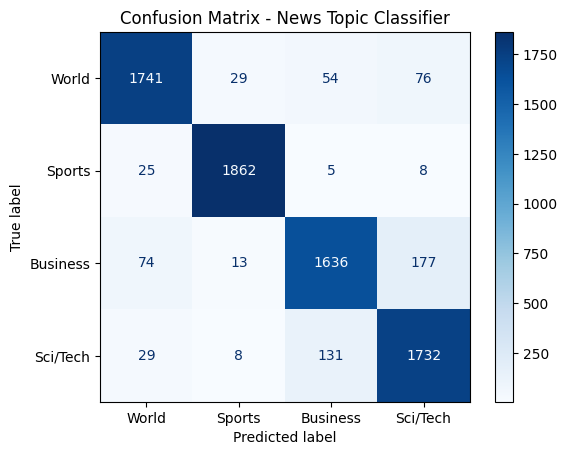

In [ ]:
# Get predictions on the test set
predictions = trainer.predict(test_dataset)

# Convert logits to predicted class labels
import numpy as np
predicted_labels = np.argmax(predictions.predictions, axis=-1)
true_labels = predictions.label_ids

# Import tools for confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Compute confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Define class names for readability
class_names = ["World", "Sports", "Business", "Sci/Tech"]

# Plot the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - News Topic Classifier")
plt.show()

## Final Summary / Insights

The fine-tuned `bert-base-uncased` model achieved a final test accuracy of **91.72%**
and F1-score of **91.72%** on the AG News dataset, using 8,000 training examples,
2,000 validation examples, and evaluated on the full 7,600-example test set.

The confusion matrix revealed that most errors occurred between the **Business** and
**Sci/Tech** categories, which is expected given that many real-world news headlines
(e.g., about tech company earnings or product launches) genuinely blend both topics.
The **Sports** and **World** categories were classified with high precision, showing
minimal confusion with other classes.

These results demonstrate that transfer learning with a pretrained transformer model
can achieve strong classification performance with a relatively small amount of
task-specific data, significantly reducing training time and computational cost
compared to training a model from scratch.

In [ ]:
# Install Gradio
!pip install gradio -q

import gradio as gr
import torch

# Function to predict the topic of a given headline
def classify_news(text):
    # Tokenize the input text the same way as training
    inputs = tokenizer(text, return_tensors="pt", padding="max_length", truncation=True, max_length=64)

    # Move inputs to the same device as the model (GPU if available)
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    # Get model prediction
    with torch.no_grad():
        outputs = model(**inputs)
        predicted_class = torch.argmax(outputs.logits, dim=-1).item()

    # Map back to category name
    class_names = ["World", "Sports", "Business", "Sci/Tech"]
    return class_names[predicted_class]

# Build the Gradio interface
demo = gr.Interface(
    fn=classify_news,
    inputs=gr.Textbox(lines=2, placeholder="Enter a news headline..."),
    outputs="text",
    title="News Topic Classifier",
    description="Enter a news headline and the model will predict its topic category (World, Sports, Business, Sci/Tech)."
)

# Launch the app
demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e0ad0998c5692d44b0.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


# Screenshots

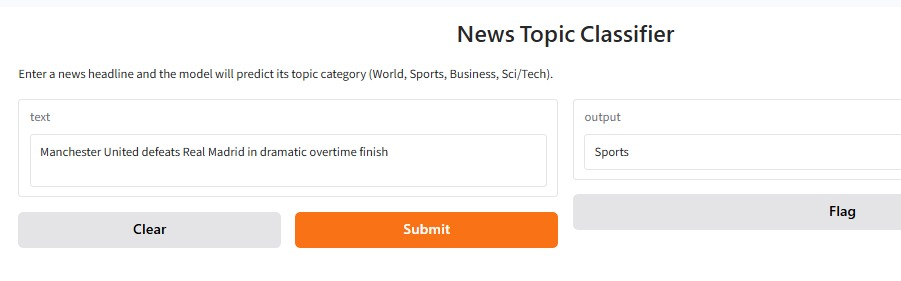                                                                              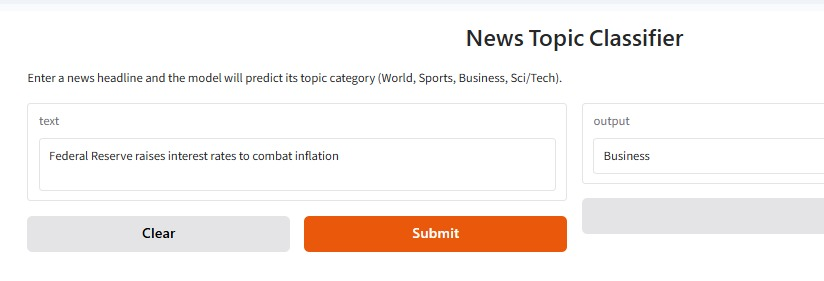                                                                          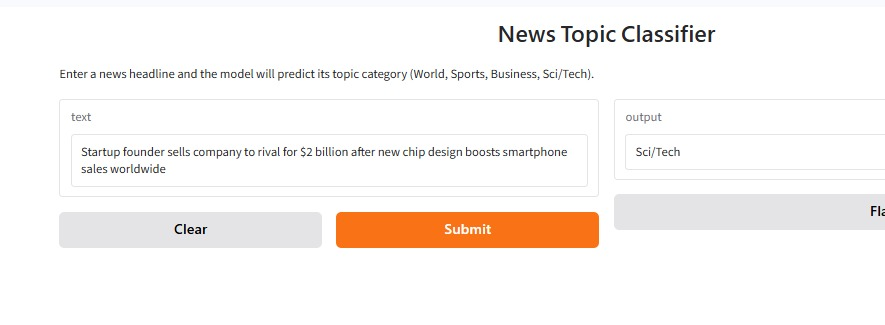